In [23]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
jan_df = pd.read_parquet("./data/yellow_tripdata_2023-01.parquet")

In [4]:
jan_df.shape

(3066766, 19)

In [5]:
jan_df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [7]:
jan_df.tpep_dropoff_datetime = pd.to_datetime(jan_df.tpep_dropoff_datetime)
jan_df.tpep_pickup_datetime = pd.to_datetime(jan_df.tpep_pickup_datetime)

jan_df["duration"] = (jan_df.tpep_dropoff_datetime - jan_df.tpep_pickup_datetime).dt.total_seconds() / 60

In [9]:
round(jan_df["duration"].std(), 2)

42.59

<Axes: >

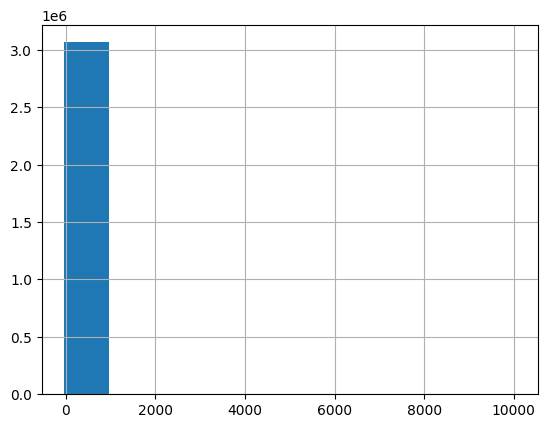

In [10]:
jan_df["duration"].hist()

In [12]:
jan_df.shape

(3066766, 20)

In [11]:
jan_df.loc[(jan_df.duration >= 1) & (jan_df.duration <= 60)].shape

(3009173, 20)

In [13]:
jan_adj_df = jan_df.loc[(jan_df.duration >= 1) & (jan_df.duration <= 60), :]

<Axes: >

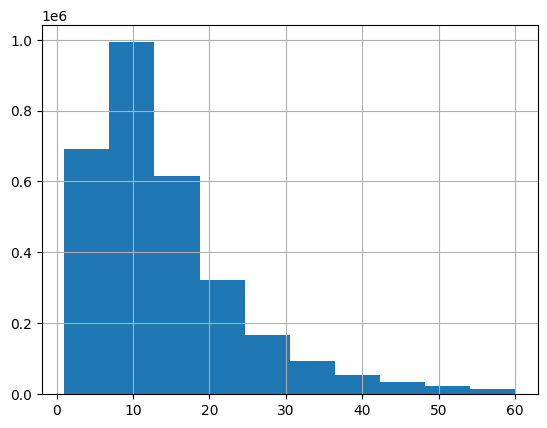

In [14]:
jan_adj_df.duration.hist()

In [18]:
round(3009173 / 3066766, 2) * 100

98.0

In [19]:
jan_adj_df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'duration'],
      dtype='object')

In [21]:
cat_features = ["PULocationID", "DOLocationID"]

jan_adj_df.loc[:, cat_features] = jan_adj_df[cat_features].astype(str)

In [22]:
jan_adj_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,duration
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00,8.433333
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00,6.316667
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00,12.750000
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25,9.616667
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00,10.833333


In [31]:
dv = DictVectorizer()

train_dicts = jan_adj_df[cat_features].to_dict(orient="records")
X_train = dv.fit_transform(train_dicts)

In [25]:
X_train.shape

(3009173, 515)

In [26]:
target = "duration"
y_train = jan_adj_df[target].values

In [27]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

mean_squared_error(y_train, y_pred, squared=False)

7.649261921255234

In [32]:
feb_df = pd.read_parquet("./data/yellow_tripdata_2023-02.parquet")

feb_df.tpep_dropoff_datetime = pd.to_datetime(feb_df.tpep_dropoff_datetime)
feb_df.tpep_pickup_datetime = pd.to_datetime(feb_df.tpep_pickup_datetime)

feb_df["duration"] = (feb_df.tpep_dropoff_datetime - feb_df.tpep_pickup_datetime).dt.total_seconds() / 60
feb_adj_df = feb_df.loc[(feb_df.duration >= 1) & (feb_df.duration <= 60), :]

cat_features = ["PULocationID", "DOLocationID"]
feb_adj_df.loc[:, cat_features] = feb_adj_df[cat_features].astype(str)

val_dicts = feb_adj_df[cat_features].to_dict(orient="records")
X_val = dv.transform(val_dicts)

target = "duration"
y_val = feb_adj_df[target].values

y_pred = lr.predict(X_val)
mean_squared_error(y_val, y_pred, squared=False)

7.811816863080594